In [17]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from scipy.ndimage import uniform_filter1d, sobel
import scipy

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [18]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

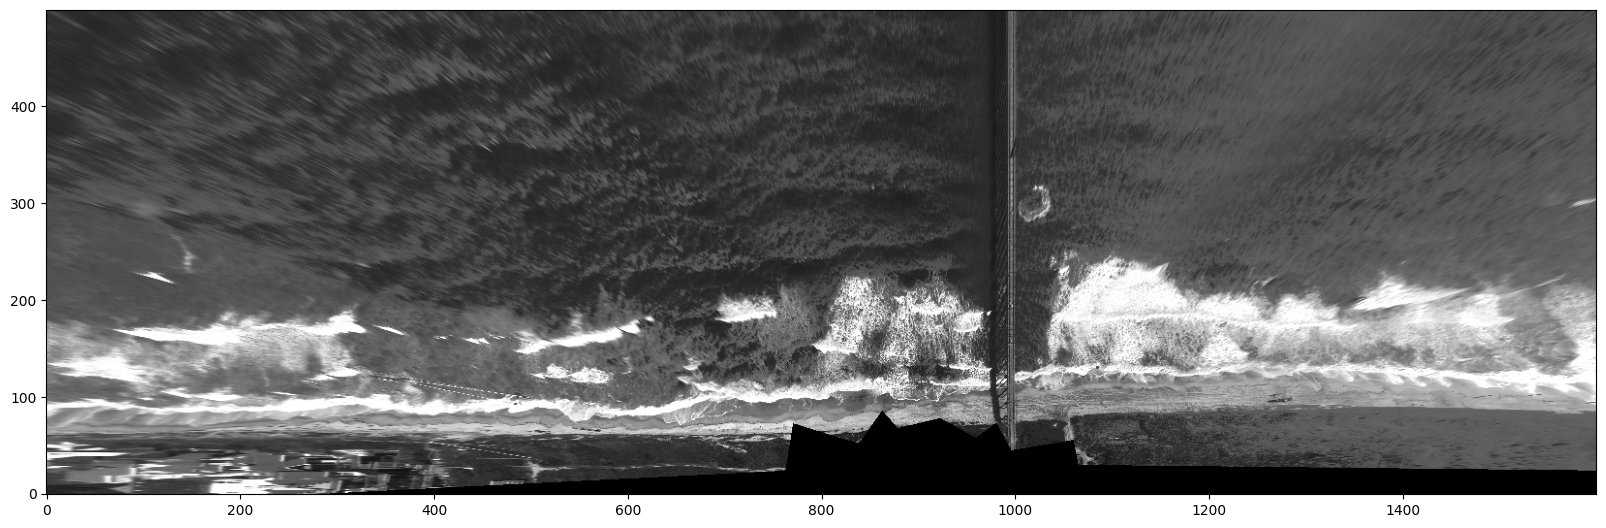

In [19]:
cap = cv2.VideoCapture(os.path.join(dir, file))
_, frame = cap.read()
frame = frame[..., 0]
plt.figure(figsize=(20, 30))
plt.imshow(frame.T)
cap.release()
cv2.destroyAllWindows()

In [20]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))

print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack
1.92mb per timestack


100%|██████████| 3840/3840 [00:05<00:00, 642.09it/s]


In [21]:
# cap = cv2.VideoCapture(fname)
# N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# FPS = int(cap.get(cv2.CAP_PROP_FPS))

# SECONDS = 10
# NFRAMES = FPS * SECONDS
# W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))


# skip = 1
# timestack = np.zeros((N-NFRAMES, H//skip, W))
# print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# buffer = np.empty((NFRAMES, H, W))

# ofname = f'ArgusFF_20211013T170100Z_RectifiedVideo_{SECONDS}s_diff.avi'
# print(ofname)
# if not os.path.isfile('diff_timestack.npy'):
#     out = cv2.VideoWriter(ofname, cv2.VideoWriter_fourcc('M','P','N','G'), FPS, (W,H), 0)
#     for i in tqdm(range(N)):
#         _, frame = cap.read()
#         buffer[i%NFRAMES] = frame[..., 0]
#         # plt.figure(figsize=(19, 6))
#         # plt.imshow((frame[..., 0] - buffer.mean(axis=0)).T)
#         # plt.colorbar()
#         # plt.show()
#         if i >= NFRAMES:
#             rolling_average = buffer.mean(axis=0)
#             diff = frame[..., 0] - rolling_average
#             diff = (diff - diff.min()) / (diff.max() - diff.min())*255
#             # plt.figure(figsize=(20, 6))
#             # plt.imshow(diff.T)
#             # plt.colorbar()
#             # plt.show()
#             out.write(diff.astype(np.uint8))
#             timestack[i-NFRAMES] = diff[::skip, :]

        
#     out.release()
#     cv2.destroyAllWindows()
#     # np.save('diff_timestack.npy', timestack) # This is like 23G on disk, not worth saving
# !  ffmpeg -i ArgusFF_20211013T170100Z_RectifiedVideo_10s_diff.avi -c:v libx264 ArgusFF_20211013T170100Z_RectifiedVideo_10s_diff.mp4 -y

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_25307/3379469075.py:3: RuntimeWarning: divide by zero encountered in log
  plt.hist(1/np.log(timestack[:500, 50, :].T))


(array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [292.,   0.,   0., ...,   1.,   1.,   0.],
        [500.,   0.,   0., ...,   0.,   0.,   0.],
        [500.,   0.,   0., ...,   0.,   0.,   0.]]),
 array([0.        , 0.04342945, 0.0868589 , 0.13028834, 0.17371779,
        0.21714724, 0.26057669, 0.30400614, 0.34743559, 0.39086503,
        0.43429448]),
 <a list of 500 BarContainer objects>)

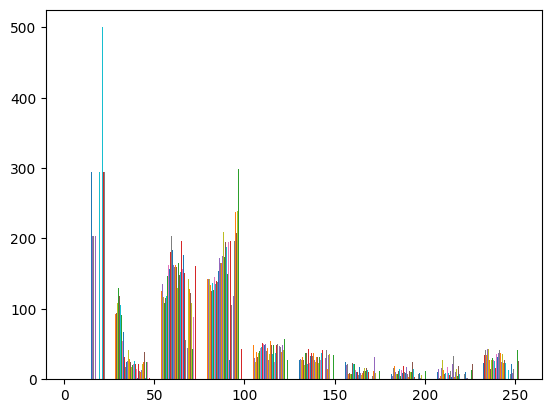

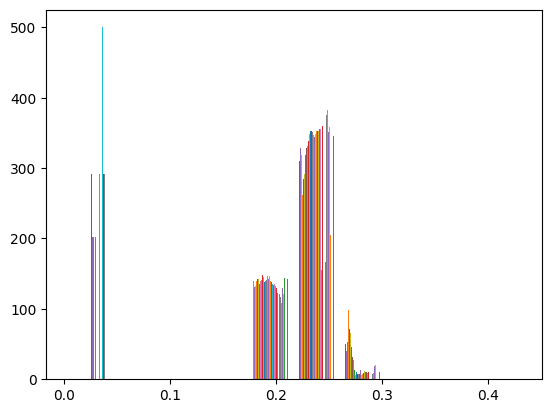

In [22]:
plt.hist(timestack[:500, 50, :].T)
plt.figure()
plt.hist(1/np.log(timestack[:500, 50, :].T))

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_25307/2257666268.py:3: RuntimeWarning: divide by zero encountered in log
  im = axs[0].imshow(np.log(timestack[:500, 50, :].T), vmin=4, vmax=np.log(255))


(0.0, 200.0)

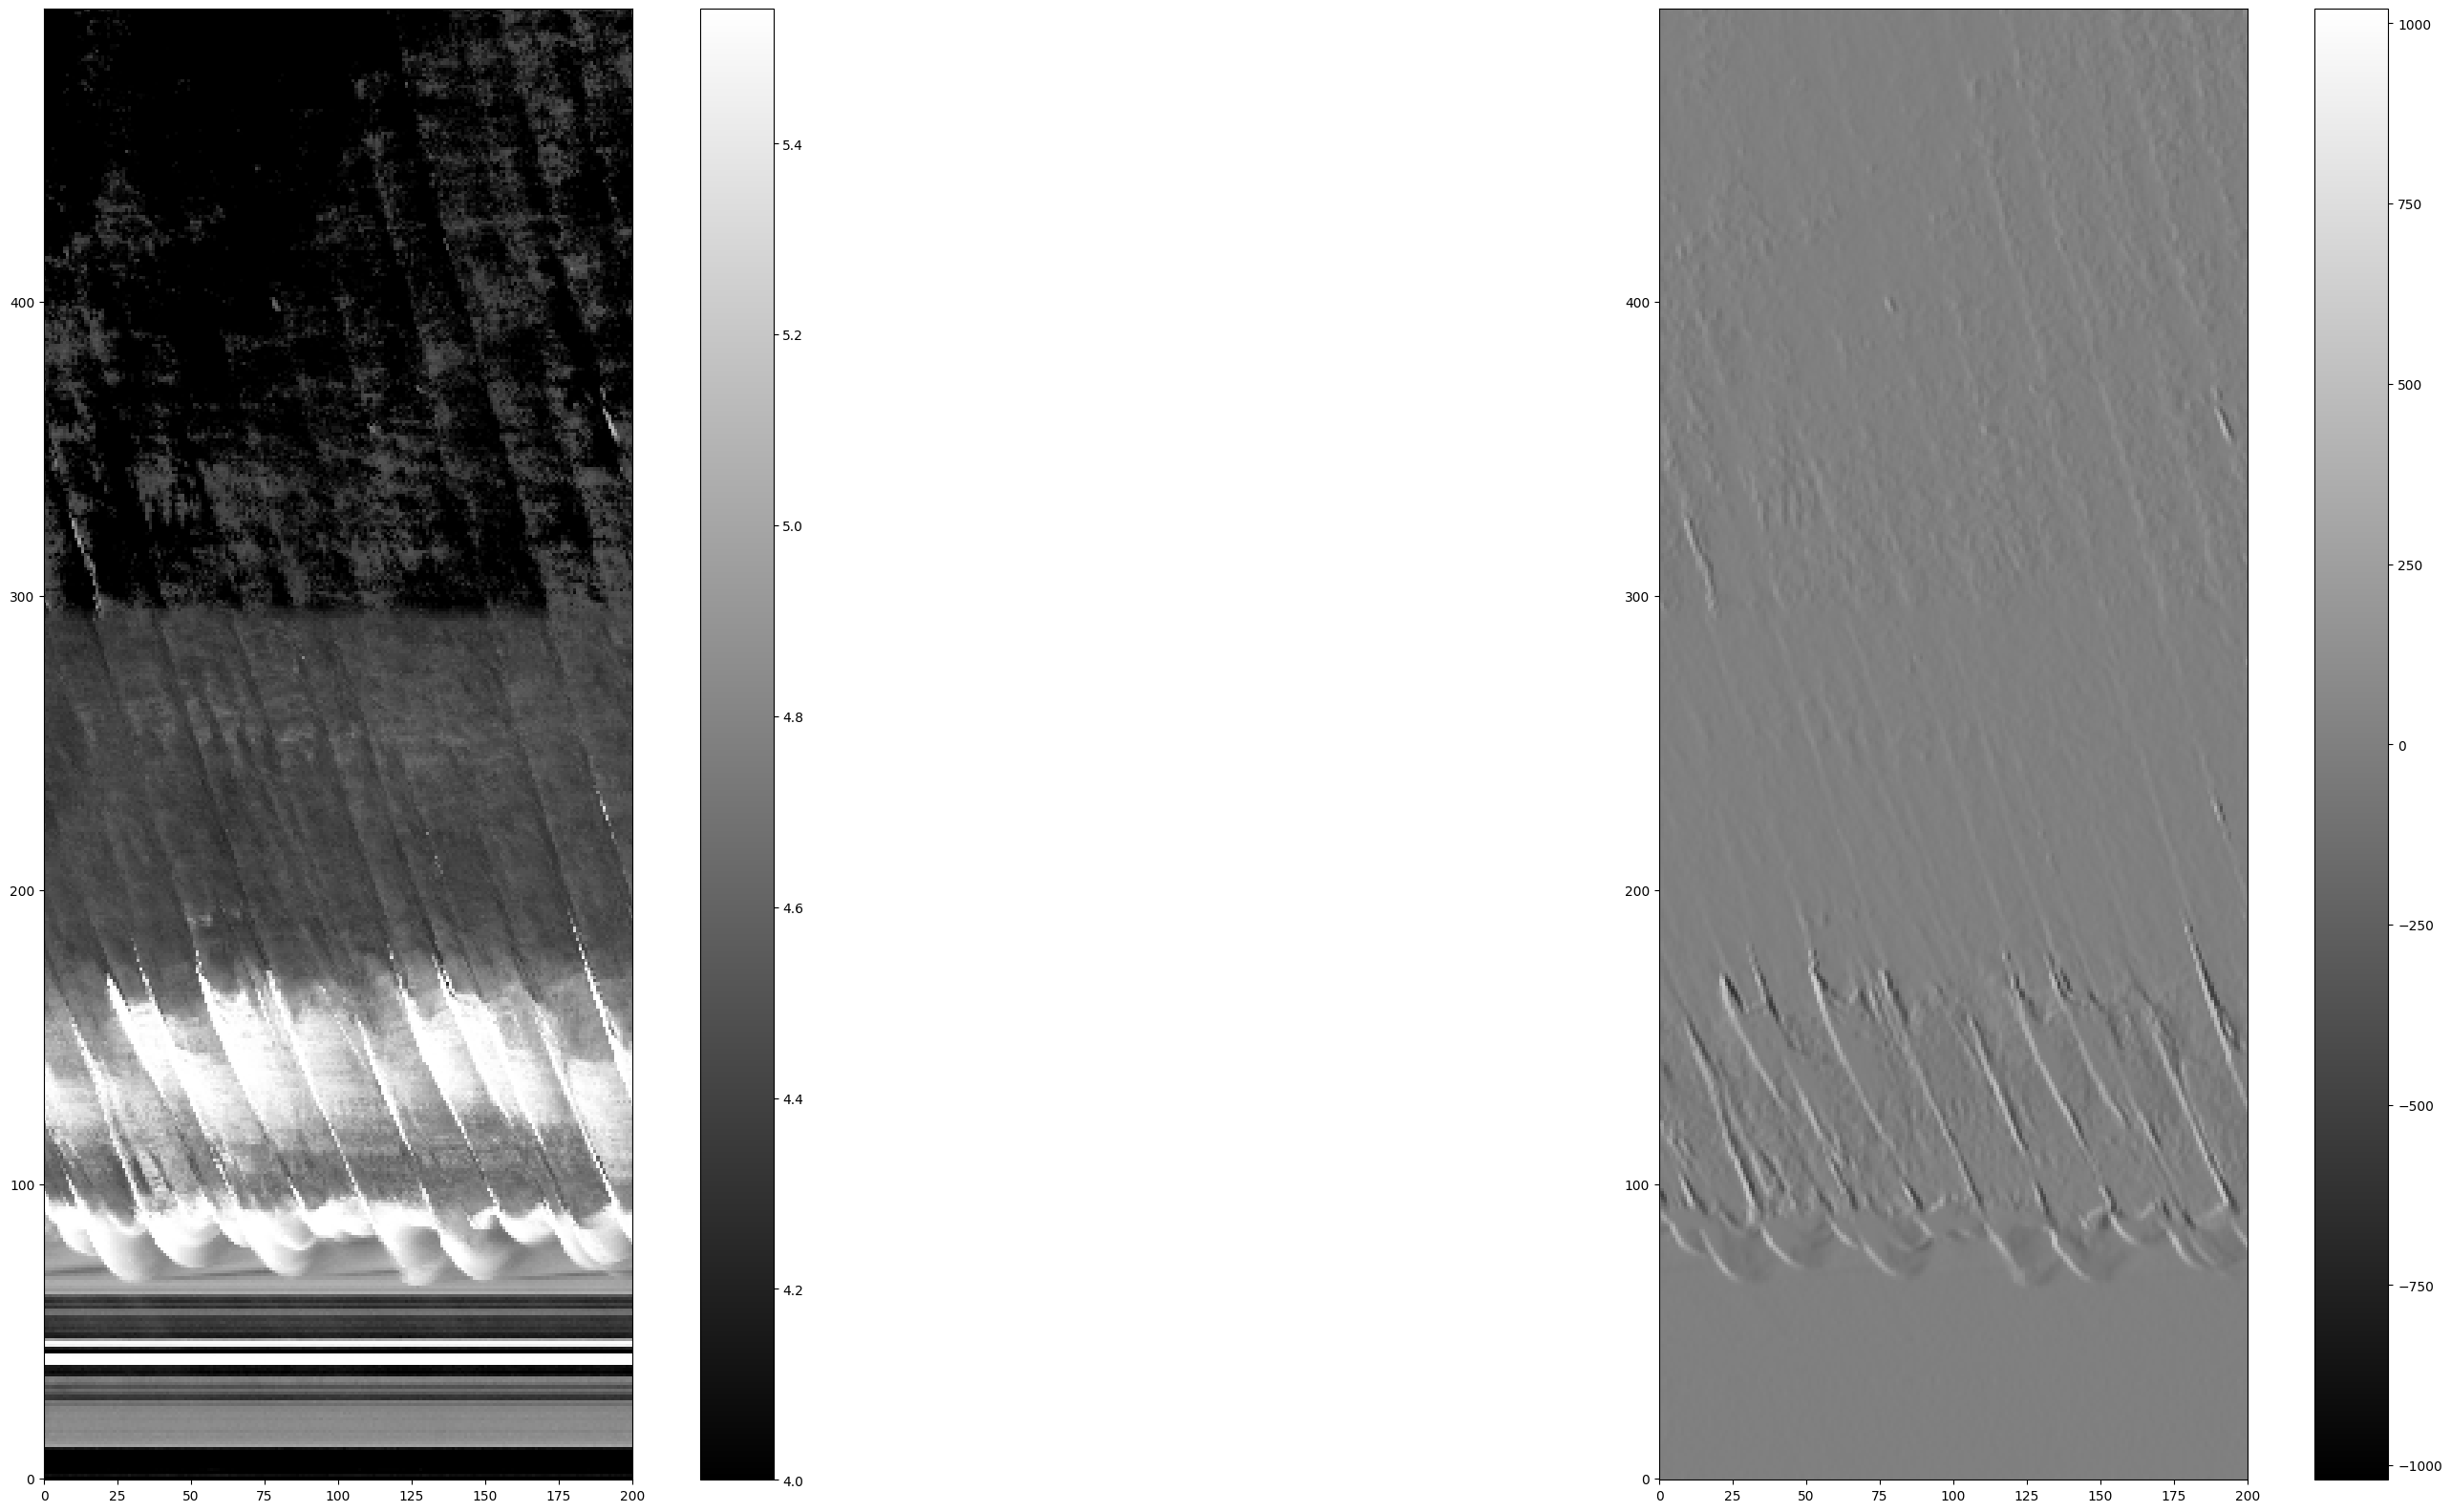

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(40,20))

im = axs[0].imshow(np.log(timestack[:500, 50, :].T), vmin=4, vmax=np.log(255))
fig.colorbar(im, ax=axs[0])
im = axs[1].imshow(sobel(timestack[:500, 50, :].T))
fig.colorbar(im, ax=axs[1])
axs[0].set_xlim([0, 200])
axs[1].set_xlim([0, 200])

(0.0, 500.0)

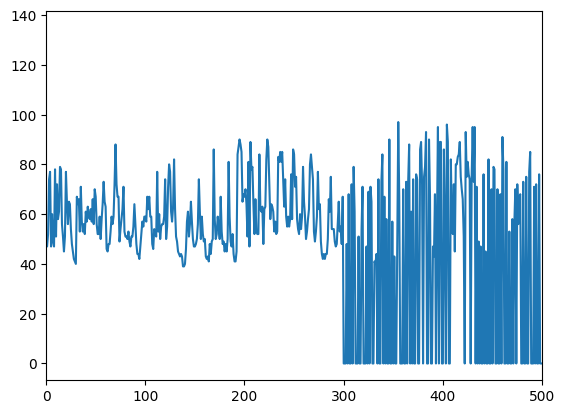

In [25]:
plt.plot(timestack[:, 500, 250])
plt.xlim([0, 500])

In [31]:
timestack.shape

(3840, 1600, 500)

In [30]:
t.shape

(500, 3840)

Text(0.5, 1.0, 'Timex - 10s Rolling Average')

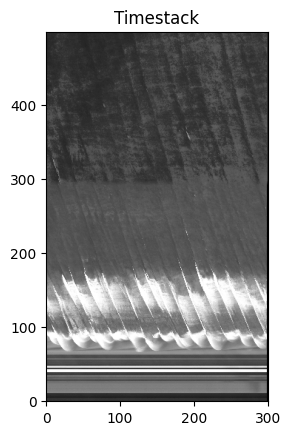

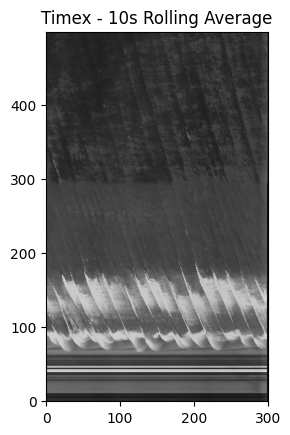

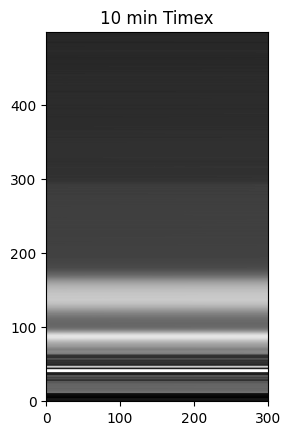

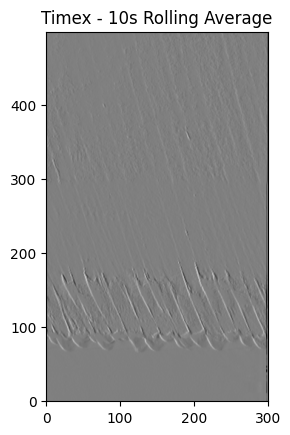

: 

In [33]:
t = timestack[:, 50, :].T
plt.imshow(t)
plt.xlim([0, 300])
plt.title('Timestack')

plt.figure()
plt.imshow(t - uniform_filter1d(np.ones_like(t) * t.mean(axis=0), 20, axis=1))
plt.xlim([0, 300])
plt.title('Timex - 10s Rolling Average')

plt.figure()
plt.imshow(uniform_filter1d(t, 10*60*60, axis=1))
plt.title('10 min Timex')
plt.xlim([0, 300])

plt.figure()
plt.imshow(sobel(t - uniform_filter1d(np.ones_like(t) * t.mean(axis=0), 20, axis=1)))
plt.xlim([0, 300])
plt.title('Timex - 10s Rolling Average')
